In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [6]:
data=pd.read_csv('diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Data Imputation

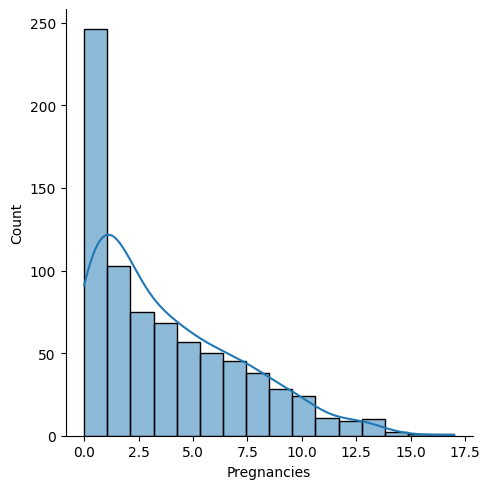

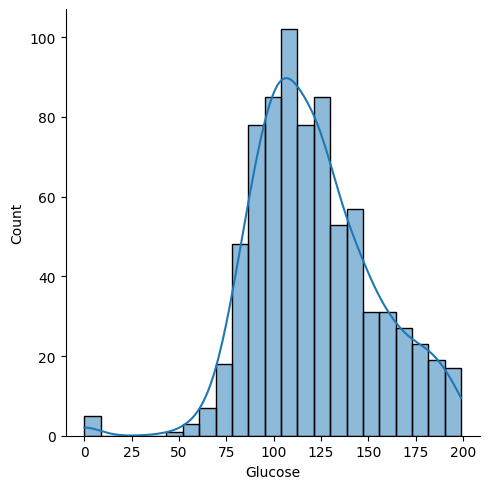

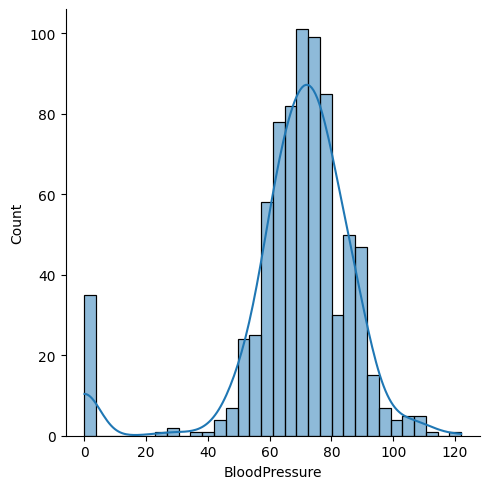

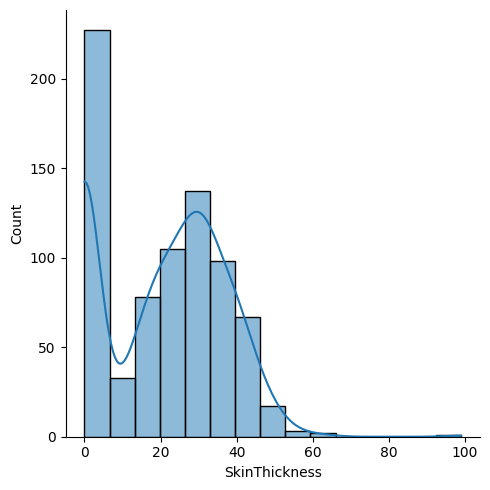

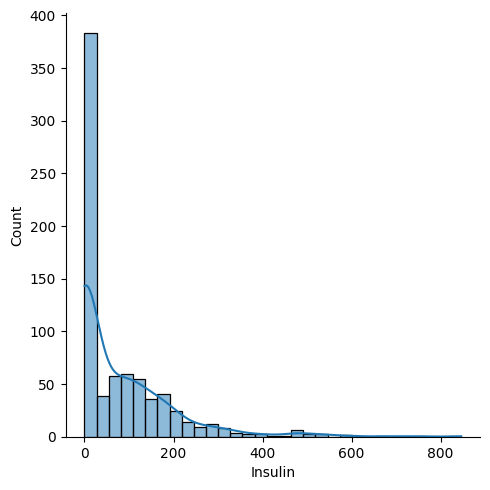

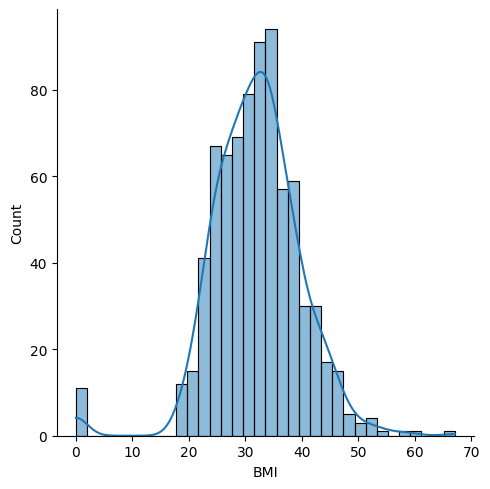

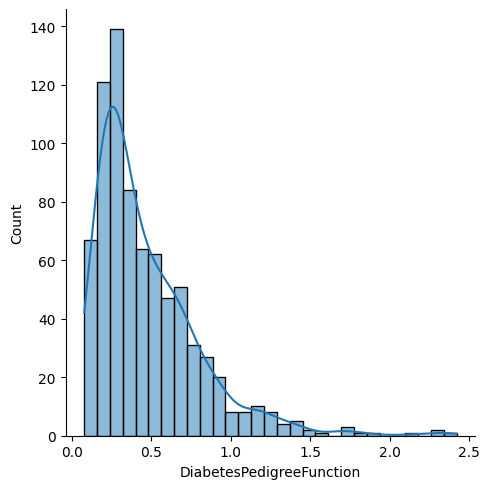

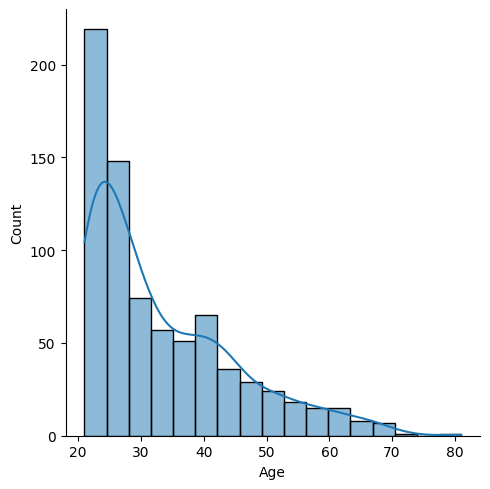

In [19]:
sns.displot(data['Pregnancies'] ,kde=True)
sns.displot(data['Glucose'] ,kde=True)
sns.displot(data['BloodPressure'] ,kde=True)
sns.displot(data['SkinThickness'] ,kde=True)
sns.displot(data['Insulin'] ,kde=True)
sns.displot(data['BMI'] ,kde=True)
sns.displot(data['DiabetesPedigreeFunction'] ,kde=True)
sns.displot(data['Age'] ,kde=True)

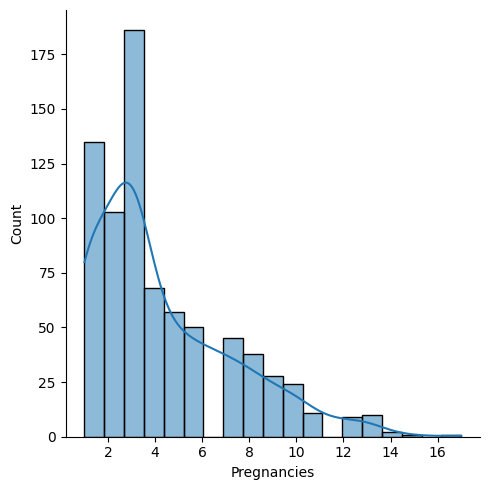

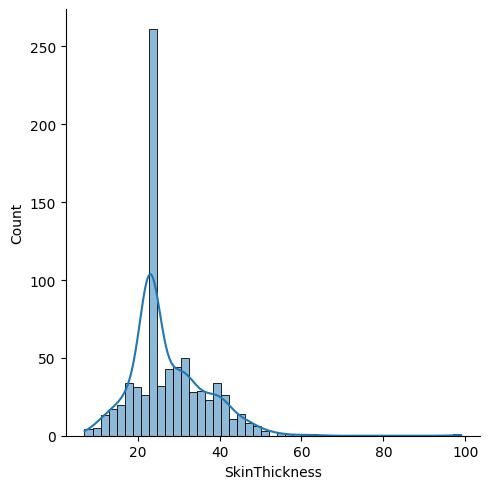

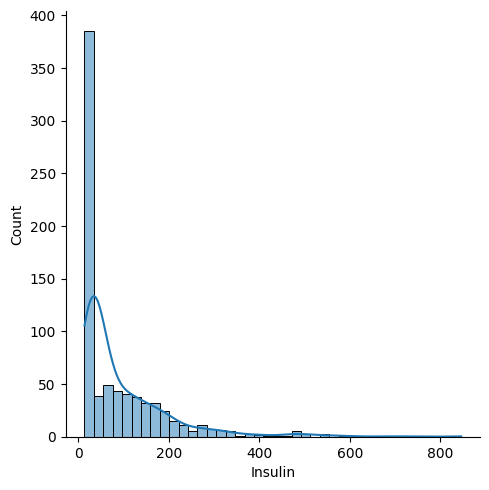

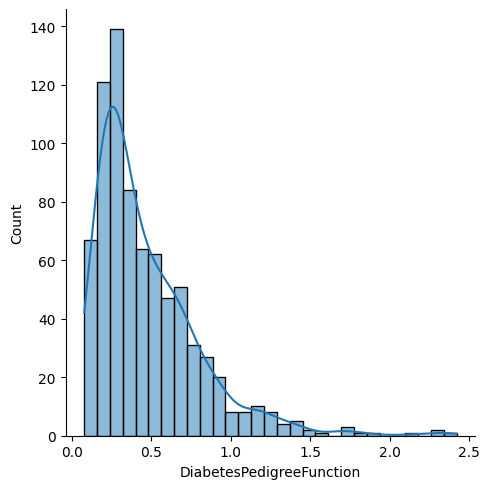

In [21]:
data['Pregnancies']=data['Pregnancies'].replace(0, data['Pregnancies'].median())
data['Glucose']=data['Glucose'].replace(0, data['Glucose'].mean())
data['BloodPressure']=data['BloodPressure'].replace(0, data['BloodPressure'].mean())
data['SkinThickness']=data['SkinThickness'].replace(0, data['SkinThickness'].median())
data['Insulin']=data['Insulin'].replace(0, data['Insulin'].median())
data['BMI']=data['BMI'].replace(0, data['BMI'].mean())
data['DiabetesPedigreeFunction']=data['DiabetesPedigreeFunction'].replace(0, data['DiabetesPedigreeFunction'].median())
data['Age']=data['Age'].replace(0, data['Age'].median())
sns.displot(data['Pregnancies'] ,kde=True)
sns.displot(data['SkinThickness'] ,kde=True)
sns.displot(data['Insulin'] ,kde=True)
sns.displot(data['DiabetesPedigreeFunction'] ,kde=True)

Split the data into the input and target features

In [7]:
## Split the data into input features and the target outcome
X=data.drop('Outcome',axis=1)
Y=data['Outcome']

Removing Outliers

<Axes: >

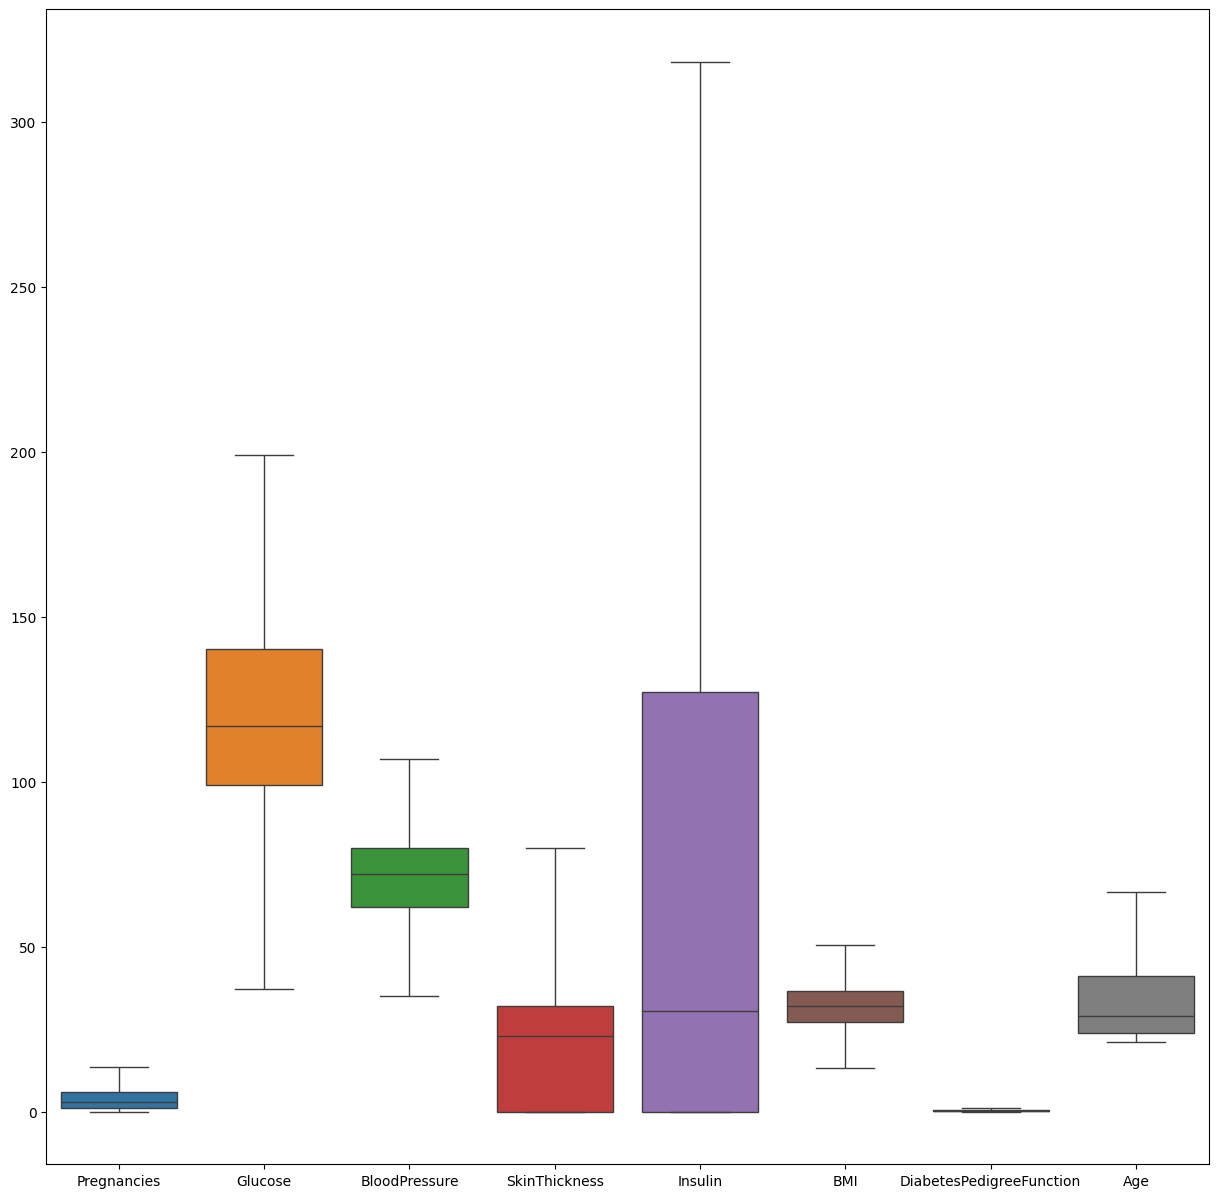

In [22]:
for i in X.columns:
    Q1=X[i].quantile(0.25)
    Q3=X[i].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    X[i]=np.where(X[i]<lower_bound, lower_bound, X[i])
    X[i]=np.where(X[i]>upper_bound, upper_bound, X[i])
fig,ax=plt.subplots(figsize=(15,15))
sns.boxplot(data=X, ax=ax)

Standard Normal Form -> Mean = 0 and standard deviation = 1

<Axes: >

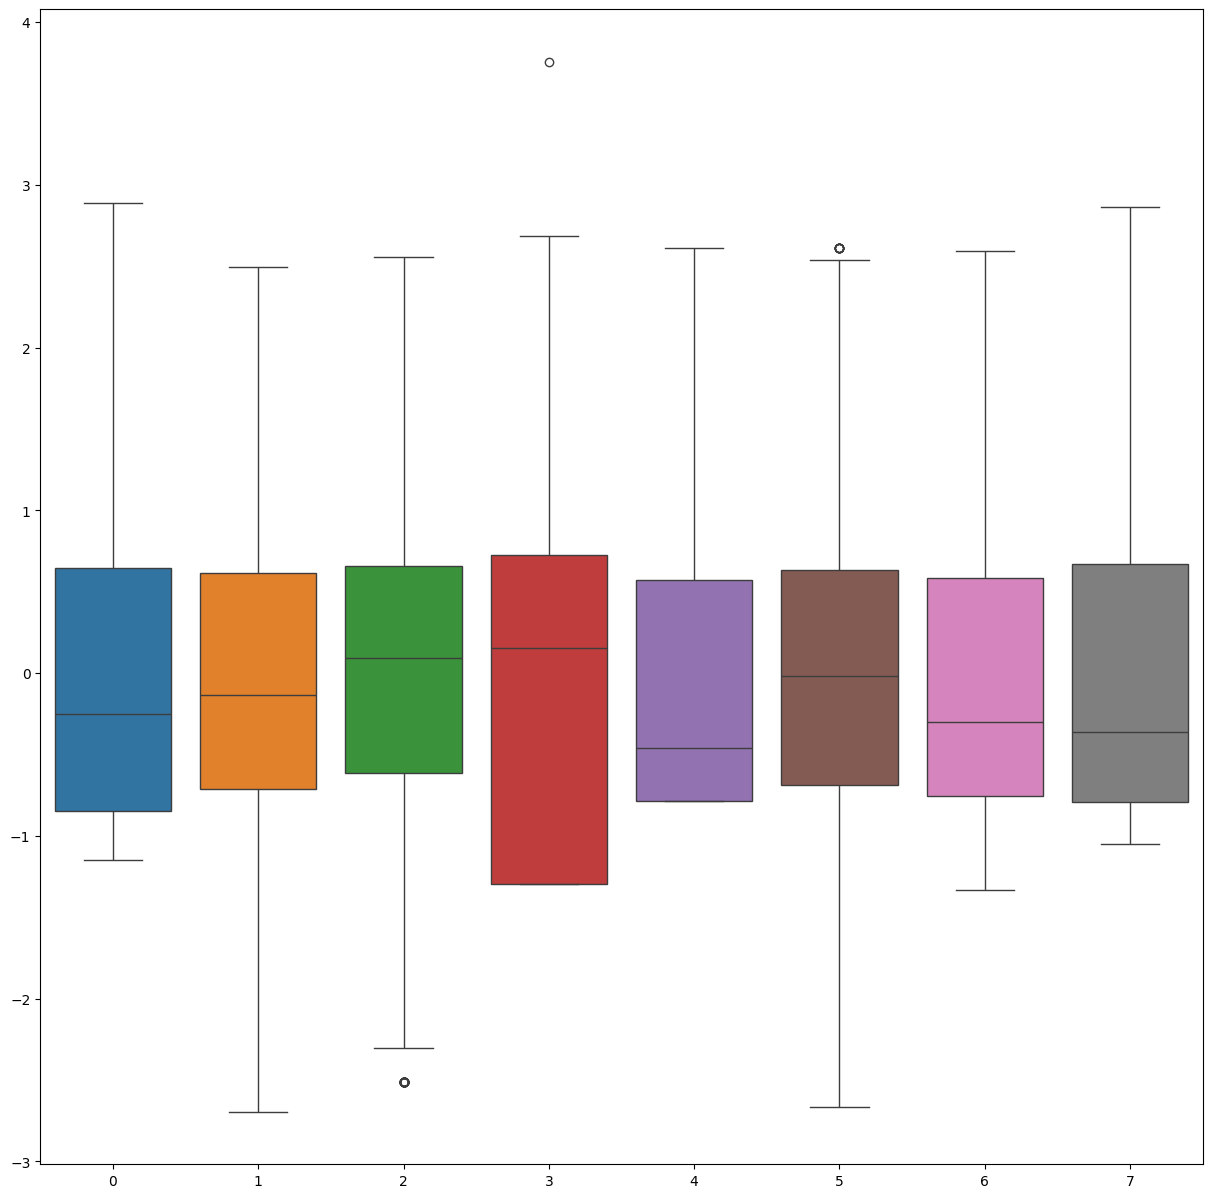

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
fig,ax=plt.subplots(figsize=(15,15))
sns.boxplot(data=X_scaled, ax=ax)

Split the entire data into two subsets(50:50):
*   Subset 1 (Train Set)
*   Subset 2 (Validation Set/Hold Out Set)

In [33]:
from sklearn.model_selection import train_test_split
train, vali_train, test, vali_test = train_test_split(X_scaled, Y, test_size = 0.5, random_state = 355)


Split the train set further into train and test set (80:20)

In [34]:
X_train,X_test,Y_train,Y_test =  train_test_split(train,test,test_size=0.2, random_state = 355)

Model 1: Implementation of KNeighboursClassifier

In [35]:
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
knn.score(X_test, Y_test)

0.7532467532467533

Model 2: Implementation of SVC Classifier

In [36]:
svc = SVC()
svc.fit(X_train, Y_train)
svc.score(X_test, Y_test)

0.7402597402597403

Predictions of the model in the validation set

In [37]:
predict_val1 = knn.predict(vali_train)
predict_val2 = svc.predict(vali_train)

In [38]:
predict_val = np.column_stack((predict_val1, predict_val2))

In [39]:
predict_test1 = knn.predict(X_test)
predict_test2 = svc.predict(X_test)
predict_test = np.column_stack((predict_test1, predict_test2))

Stacking: Input features are the predictions of the model M1(KNN) and model M2(SVC) stored inside the predict_val(input features) for the RandomForestClassifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
rand_cla = RandomForestClassifier()
rand_cla.fit(predict_val, vali_test)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rand_cla.score(predict_test, Y_test)

0.7402597402597403